In [1]:
# Suppress distracting outputs in these examples
# Note: this cell should be hidden with the tag "hide-cell"
import logging
import warnings

from rich import print

warnings.filterwarnings("ignore", category=UserWarning)
logger = logging.getLogger("esmvalcore")
logger.setLevel(logging.WARNING)

# Models

In [2]:
import ewatercycle.models

/opt/conda/envs/ewc26/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In eWaterCycle models can be added as plugins. The ewatercycle package itself does not ship with any models.
Depending on who set up your system, some or all of the following models will already be available:

* ["leaky bucket" toy model](https://github.com/eWaterCycle/ewatercycle-leakybucket)
* [wflow](https://github.com/eWaterCycle/ewatercycle-wflow)
* [pcrglobwb](https://github.com/eWaterCycle/ewatercycle-pcrglobwb)
* [marrmot M01](https://github.com/eWaterCycle/ewatercycle-marrmot)
* [marrmot M14](https://github.com/eWaterCycle/ewatercycle-marrmot)
* [lisflood](https://github.com/eWaterCycle/ewatercycle-lisflood)
* [hype](https://github.com/eWaterCycle/ewatercycle-hype)
* [HBV](https://github.com/eWaterCycle/ewatercycle-hbv)
* [SWMM](https://github.com/eWaterCycle/ewatercycle-swmm/)

The process for adding new models is documented in [Adding models](https://ewatercycle.readthedocs.io/en/latest/adding_models.html)

To show the currently available models do:

In [3]:
print(ewatercycle.models.sources)

ModelSources[
    "HBV",
    "HBVLocal",
    "Hype",
    "LeakyBucket",
    "Lisflood",
    "MarrmotM01",
    "MarrmotM14",
    "PCRGlobWB",
    "SWMM",
    "Wflow",
    "WflowJl",
]

## Creating, setting up, and initializing a model instance

The way models are created, setup, and initialized matches [PyMT](https://pymt.readthedocs.io/en/latest/quickstart.html#run-a-model) as much as possible.
To see the all available methods and properties, see the [API reference for the eWaterCycleModel](#ewatercycle.base.model.eWaterCycleModel){.external}.

There are three main steps required before running a model:

- instantiate (create a python object that represents the model)
- setup (create a container with the right model, directories, and configuration files)
- initialize (start the model inside the container)

To a new user, these steps can be confusing as they seem to be related to "starting a model". However, you will see that there are some useful things that we can do in between each of these steps. As a side effect, splitting these steps also makes it easier to run a lot of models in parallel (e.g. for calibration). Experience tells us that you will quickly get used to it. 

When a model instance is created, we have to specify the version and pass in a suitable parameter set and forcing. 

In [4]:
import ewatercycle.forcing
import ewatercycle.models
import ewatercycle.parameter_sets

parameter_set = ewatercycle.parameter_sets.available_parameter_sets(
    target_model="wflow"
)["wflow_rhine_sbm_nc"]
forcing = ewatercycle.forcing.sources["WflowForcing"](
    directory=str(parameter_set.directory),
    start_time="1991-01-01T00:00:00Z",
    end_time="1991-12-31T00:00:00Z",
    shape=None,
    # Additional information about the external forcing data needed for the model configuration
    netcdfinput="inmaps.nc",
    Precipitation="/P",
    EvapoTranspiration="/PET",
    Temperature="/TEMP",
)

In [5]:
model_instance = ewatercycle.models.Wflow(
    version="2020.1.3", parameter_set=parameter_set, forcing=forcing
)

In some specific cases the parameter set (e.g. for marrmot) or the forcing (e.g. when it is already included in the parameter set) is not needed.

Most models have a variety of parameters that can be set. An opiniated subset of these parameters is exposed through the eWaterCycle API. We focus on those settings that are relevant from a scientific point of view and prefer to hide technical settings. These parameters and their default values can be inspected as follows:

In [6]:
model_instance.parameters

dict_items([('start_time', '1991-01-01T00:00:00Z'), ('end_time', '1991-12-31T00:00:00Z')])

The start date and end date are automatically set based on the forcing data. 

Alternative values for each of these parameters can be passed on to the setup function:

In [7]:
cfg_file, cfg_dir = model_instance.setup(
    end_time="1991-12-15T00:00:00Z",
    # use `cfg_dir="/path/to/output_dir"` to specify the output directory
)

The `setup` function does the following:

- Create a config directory which serves as the current working directory for the mode instance
- Creates a configuration file in this directory based on the settings
- Starts a container with the requested model version and access to the forcing and parameter sets.
- Input is mounted read-only, the working directory is mounted read-write (if a model cannot cope with inputs outside the working directory, the input will be copied).
- Setup will complain about incompatible model version, parameter_set, and forcing.

After `setup` but before `initialize` everything is good-to-go, but nothing has been done yet. This is
an opportunity to inspect the generated configuration file, and make any changes manually that could not be
done through the setup method. 

To modify the config file: print the path, open it in an editor, and save:

In [8]:
print(cfg_file)

/home/mmelotto/ewatercycle/docs/user_guide/wflow_20260915_134727/wflow_ewatercycle.ini

Once you're happy with the setup, it is time to initialize the model. You'll have to pass in the config file, even if you've not made any changes:

In [9]:
model_instance.initialize(cfg_file)  # for some models, this step can take some time

Note that if anything goes wrong on the model side during initialization or at any other point in time you can inspect the model's logs. For example, if some input file is missing or corrupt.
In this case you would do:

```py
print(model_instance.logs)
```

## Running (and interacting with) a model

A model instance can be controlled by calling functions for running a single timestep (`update`), setting variables, and getting variables. Besides the rather lowlevel BMI functions like `get_value` and `set_value`, we also added convenience functions such as `get_value_as_xarray`, `get_value_at_coords`, `time_as_datetime`, and `time_as_isostr`. These make it even more pleasant to interact with the model.

For example, to run our model instance from start to finish, fetching the value of variable `discharge` at the location of a grdc station:

In [10]:
grdc_latitude = 51.756918
grdc_longitude = 6.395395

In [11]:
output = []
timestamps = []
while model_instance.time < model_instance.end_time:
    model_instance.update()

    discharge = model_instance.get_value_at_coords(
        "RiverRunoff", lon=[grdc_longitude], lat=[grdc_latitude]
    )[0]
    output.append(discharge)
    timestamps.append(model_instance.time_as_datetime)

    # Here you could do whatever you like, e.g. update soil moisture values before doing the next timestep.

    print(
        model_instance.time_as_isostr,
        end="\r",
        flush=True,
    )  # "\r" clears the output before printing the next timestamp

1991-01-01T00:00:00Z

1991-01-02T00:00:00Z

1991-01-03T00:00:00Z

1991-01-04T00:00:00Z

1991-01-05T00:00:00Z

...

1991-12-11T00:00:00Z

1991-12-12T00:00:00Z

1991-12-13T00:00:00Z

1991-12-14T00:00:00Z

1991-12-15T00:00:00Z

We can also get the entire model field at a single time step. To simply plot it:

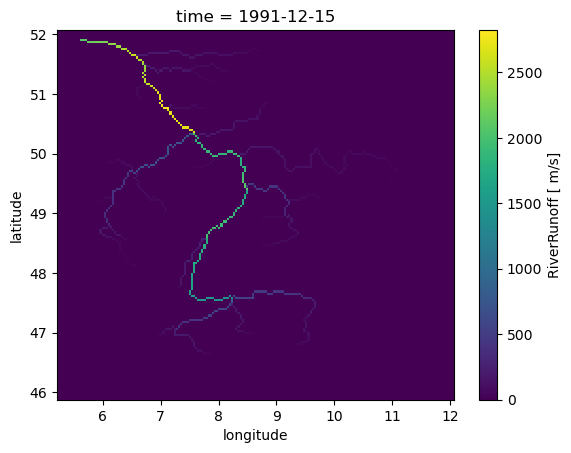

In [12]:
model_instance.get_value_as_xarray("RiverRunoff").plot()

To get the RiverRunoff at certain location

In [13]:
model_instance.get_value_at_coords("RiverRunoff", lat=[50.0], lon=[8.05])

array([1850.8435], dtype=float32)

If you want to know which variables are available, you can use

In [14]:
model_instance.output_var_names

('RiverRunoff',)

If you for some reason need to interact with the underlying Basic Model Interface of the model, you can access it in the following way:

In [15]:
model_instance.bmi.get_component_name()

'sbm'

In [16]:
model_start_time = model_instance.start_time_as_isostr
model_end_time = model_instance.end_time_as_isostr

## Destroying the model

A model instance running in a container can take up quite a bit of resources on the system. When you're done with an experiment, it is good practice to always finalize the model. This will make sure the model properly performs any tear-down tasks and eventually the container will be destroyed.

In [17]:
model_instance.finalize()

# Observations

eWaterCycle also includes utilities to easily load observations. Currently, eWaterCycle systems provide access to GRDC and USGS data, and we're hoping to expand this in the future.

In [18]:
import ewatercycle.observation.grdc

To load GRDC station data:

In [19]:
grdc_station_id = "6335020"

observations = ewatercycle.observation.grdc.get_grdc_data(
    station_id=grdc_station_id,
    start_time=model_start_time,
    end_time=model_end_time,
    column="GRDC",
)

observations.GRDC.to_dataframe().head()

,id,GRDC
time,,
1991-01-01,6335020,4510.0
1991-01-02,6335020,4850.0
1991-01-03,6335020,5190.0
1991-01-04,6335020,5500.0
1991-01-05,6335020,6020.0


Since not all GRDC stations are complete, some information is stored in metadata to inform you about the data.

In [20]:
print(observations.attrs)

{
    'title': 'MEAN DAILY DISCHARGE (Q)',
    'Conventions': 'CF-1.7',
    'references': 'grdc.bafg.de',
    'institution': 'GRDC',
    'history': 'Converted from 6335020_Q_Day.Cmd.txt of 2019-03-27 to netcdf by eWaterCycle Python package',
    'missing_value': '-999.000'
}

# Analysis

To easily analyse model output, eWaterCycle also includes an `analysis` module.

In [21]:
import pandas as pd

import ewatercycle.analysis

For example, we will plot a hydrograph of the model run and GRDC observations. To this end, we combine the two timeseries in a single dataframe

In [22]:
model_discharge = pd.Series(output, index=pd.DatetimeIndex(timestamps), name="wflow")

combined_discharge = (
    observations["GRDC"].to_dataframe()[["GRDC"]].join(model_discharge, how="inner")
)

(<Figure size 1000x1000 with 2 Axes>,
 (<Axes: title={'center': '$\\mathbf{Hydrograph\\ with\\ Metrics}$\nReference: GRDC'}, ylabel='Discharge (m$^3$ s$^{-1}$)'>,
  <Axes: >))

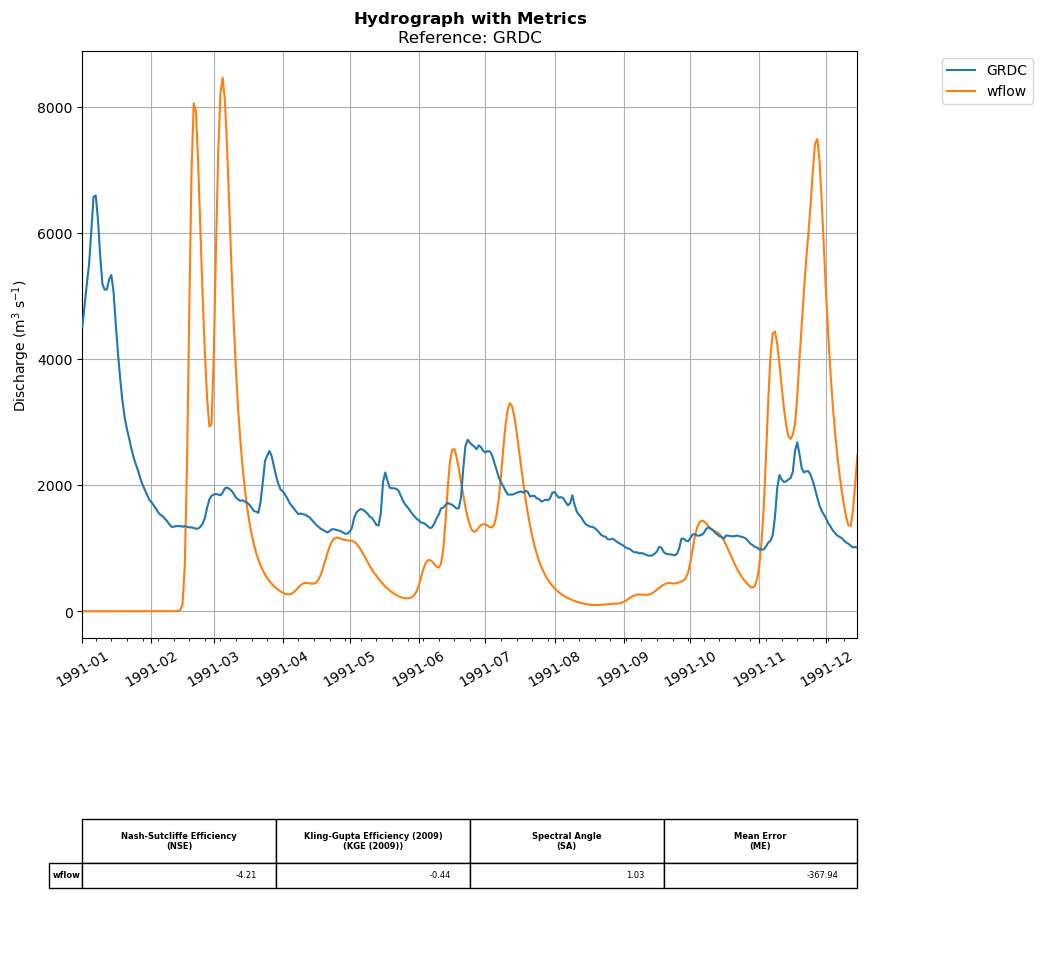

In [23]:
ewatercycle.analysis.hydrograph(
    discharge=combined_discharge,
    reference="GRDC",
)